TASK 4: MACHINE LEARNING

Perform the following:

    Load the dataset and inspect the data structure.

    Split the data into training and testing sets.

    Train at least 5 different machine learning models.

    Tune model hyperparameters (use any appropriate method).

    Evaluate and compare the models using suitable performance metrics.

    Present the best performing model and summarize the results.

Deliverable:Model comparison table, evaluation metrics, and a justified selection of the final model.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix, 
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}, Scikit-learn: {sklearn.__version__}")

Libraries imported successfully!
Pandas: 3.0.5, NumPy: 2.5.2, Scikit-learn: 1.9.0


In [3]:
# Step 1: Load and inspect the data
print("="*80)
print("STEP 1: LOAD AND INSPECT DATA")
print("="*80)

# Load the wrangled dataset from Task 2
df = pd.read_csv('wrangled_customer_data.csv')

print(f"\nDataset Shape: {df.shape}")
print(f"\nColumn Names and Types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())
print(f"\nBasic Statistics:")
print(df.describe())

STEP 1: LOAD AND INSPECT DATA

Dataset Shape: (10000, 19)

Column Names and Types:
ID                           str
Age_Years                  int64
Gender                       str
Marital_Status               str
Education                    str
Employment                   str
Account_Tenure_Months      int64
Account_Balance            int64
Transaction_Frequency      int64
Product_Count              int64
Number_of_Complaints       int64
Satisfaction_Rate        float64
Support_Calls              int64
Email_Subscription         int64
Has_Credit_Card            int64
Churn_Status               int64
Customer_Value_Score     float64
Engagement_Level             str
Risk_Profile                 str
dtype: object

First few rows:
         ID  Age_Years  Gender Marital_Status  Education     Employment  \
0  CUST1180         40    Male        Married        NaN       Employed   
1  CUST1160         56  Female        Married  Secondary  Self-employed   
2  CUST2521         27    Male    

In [4]:
# Step 2: Data preparation - encode categorical variables and scale features
print("\n" + "="*80)
print("STEP 2: DATA PREPARATION")
print("="*80)

# Separate features and target
X = df.drop(['Churn_Status'], axis=1)
y = df['Churn_Status']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget proportions:")
print(y.value_counts(normalize=True))

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nCategorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

# Encode categorical variables
label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nEncoded features shape: {X_encoded.shape}")
print(f"Encoded features dtypes:\n{X_encoded.dtypes}")


STEP 2: DATA PREPARATION

Features shape: (10000, 18)
Target shape: (10000,)

Target distribution:
Churn_Status
0    7268
1    2732
Name: count, dtype: int64

Target proportions:
Churn_Status
0    0.7268
1    0.2732
Name: proportion, dtype: float64

Categorical columns: ['ID', 'Gender', 'Marital_Status', 'Education', 'Employment', 'Engagement_Level', 'Risk_Profile']
Numerical columns: ['Age_Years', 'Account_Tenure_Months', 'Account_Balance', 'Transaction_Frequency', 'Product_Count', 'Number_of_Complaints', 'Satisfaction_Rate', 'Support_Calls', 'Email_Subscription', 'Has_Credit_Card', 'Customer_Value_Score']
Encoded ID: {'CUST0001': np.int64(0), 'CUST0002': np.int64(1), 'CUST0003': np.int64(2), 'CUST0004': np.int64(3), 'CUST0005': np.int64(4), 'CUST0006': np.int64(5), 'CUST0007': np.int64(6), 'CUST0008': np.int64(7), 'CUST0009': np.int64(8), 'CUST0010': np.int64(9), 'CUST0011': np.int64(10), 'CUST0012': np.int64(11), 'CUST0013': np.int64(12), 'CUST0014': np.int64(13), 'CUST0015': np.in

In [5]:
# Step 3: Split data into training and testing sets
print("\n" + "="*80)
print("STEP 3: TRAIN-TEST SPLIT")
print("="*80)

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTesting set target distribution:")
print(y_test.value_counts())

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled successfully!")
print(f"Training set mean: {X_train_scaled.mean(axis=0)[:5]}")  # First 5 features
print(f"Training set std: {X_train_scaled.std(axis=0)[:5]}")    # First 5 features


STEP 3: TRAIN-TEST SPLIT

Training set size: (8000, 18)
Testing set size: (2000, 18)

Training set target distribution:
Churn_Status
0    5814
1    2186
Name: count, dtype: int64

Testing set target distribution:
Churn_Status
0    1454
1     546
Name: count, dtype: int64

Features scaled successfully!
Training set mean: [ 6.92779167e-17 -3.30402372e-16 -3.19744231e-17  2.65565347e-16
 -8.17124146e-17]
Training set std: [1. 1. 1. 1. 1.]


In [6]:
# Step 4: Train initial models (without hyperparameter tuning)
print("\n" + "="*80)
print("STEP 4: TRAIN INITIAL MODELS")
print("="*80)

# Dictionary to store trained models
models = {}
predictions = {}
probabilities = {}

# Model 1: Logistic Regression
print("\n--- Model 1: Logistic Regression ---")
lr_model = LogisticRegression(random_state=42, max_iter=1000, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model
predictions['Logistic Regression'] = lr_model.predict(X_test_scaled)
probabilities['Logistic Regression'] = lr_model.predict_proba(X_test_scaled)[:, 1]
print(f"Training accuracy: {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing accuracy: {lr_model.score(X_test_scaled, y_test):.4f}")

# Model 2: Decision Tree Classifier
print("\n--- Model 2: Decision Tree ---")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train_scaled, y_train)
models['Decision Tree'] = dt_model
predictions['Decision Tree'] = dt_model.predict(X_test_scaled)
probabilities['Decision Tree'] = dt_model.predict_proba(X_test_scaled)[:, 1]
print(f"Training accuracy: {dt_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing accuracy: {dt_model.score(X_test_scaled, y_test):.4f}")

# Model 3: Random Forest Classifier
print("\n--- Model 3: Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model
predictions['Random Forest'] = rf_model.predict(X_test_scaled)
probabilities['Random Forest'] = rf_model.predict_proba(X_test_scaled)[:, 1]
print(f"Training accuracy: {rf_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing accuracy: {rf_model.score(X_test_scaled, y_test):.4f}")

# Model 4: Gradient Boosting Classifier
print("\n--- Model 4: Gradient Boosting ---")
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb_model.fit(X_train_scaled, y_train)
models['Gradient Boosting'] = gb_model
predictions['Gradient Boosting'] = gb_model.predict(X_test_scaled)
probabilities['Gradient Boosting'] = gb_model.predict_proba(X_test_scaled)[:, 1]
print(f"Training accuracy: {gb_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing accuracy: {gb_model.score(X_test_scaled, y_test):.4f}")

# Model 5: Support Vector Machine
print("\n--- Model 5: Support Vector Machine (SVM) ---")
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)
models['SVM'] = svm_model
predictions['SVM'] = svm_model.predict(X_test_scaled)
probabilities['SVM'] = svm_model.predict_proba(X_test_scaled)[:, 1]
print(f"Training accuracy: {svm_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing accuracy: {svm_model.score(X_test_scaled, y_test):.4f}")

print("\n✓ All 5 models trained successfully!")


STEP 4: TRAIN INITIAL MODELS

--- Model 1: Logistic Regression ---
Training accuracy: 0.7275
Testing accuracy: 0.7250

--- Model 2: Decision Tree ---
Training accuracy: 0.7825
Testing accuracy: 0.6990

--- Model 3: Random Forest ---
Training accuracy: 0.9316
Testing accuracy: 0.7230

--- Model 4: Gradient Boosting ---
Training accuracy: 0.7935
Testing accuracy: 0.7125

--- Model 5: Support Vector Machine (SVM) ---
Training accuracy: 0.7319
Testing accuracy: 0.7270

✓ All 5 models trained successfully!


In [7]:
# Step 5: Evaluate initial models
print("\n" + "="*80)
print("STEP 5: EVALUATE INITIAL MODELS")
print("="*80)

# Calculate metrics for all models
results = []

for model_name in models.keys():
    y_pred = predictions[model_name]
    y_pred_proba = probabilities[model_name]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON (Initial Models)")
print("="*80)
print(results_df.to_string(index=False))


STEP 5: EVALUATE INITIAL MODELS

Logistic Regression:
  Accuracy:  0.7250
  Precision: 0.3333
  Recall:    0.0073
  F1-Score:  0.0143
  ROC-AUC:   0.6246

Decision Tree:
  Accuracy:  0.6990
  Precision: 0.3108
  Recall:    0.0842
  F1-Score:  0.1326
  ROC-AUC:   0.5743

Random Forest:
  Accuracy:  0.7230
  Precision: 0.3667
  Recall:    0.0201
  F1-Score:  0.0382
  ROC-AUC:   0.6090

Gradient Boosting:
  Accuracy:  0.7125
  Precision: 0.3371
  Recall:    0.0549
  F1-Score:  0.0945
  ROC-AUC:   0.5928

SVM:
  Accuracy:  0.7270
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.5556

MODEL COMPARISON (Initial Models)
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression    0.7250   0.333333 0.007326  0.014337 0.624600
      Random Forest    0.7230   0.366667 0.020147  0.038194 0.608974
  Gradient Boosting    0.7125   0.337079 0.054945  0.094488 0.592794
      Decision Tree    0.6990   0.310811 0.084249  0.132565 0.574287
       

In [8]:
# Step 6: Hyperparameter Tuning using GridSearchCV
print("\n" + "="*80)
print("STEP 6: HYPERPARAMETER TUNING")
print("="*80)

# Dictionary to store tuned models
tuned_models = {}
tuned_predictions = {}
tuned_probabilities = {}

# Hyperparameter grids for each model
param_grids = {
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'max_iter': [500, 1000, 2000]
    },
    'Decision Tree': {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 150],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale']
    }
}

# Tune each model (using 3-fold CV for faster tuning)
for model_name, model in models.items():
    print(f"\nTuning {model_name}...")
    param_grid = param_grids[model_name]
    
    grid_search = GridSearchCV(
        model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0
    )
    grid_search.fit(X_train_scaled, y_train)
    
    tuned_models[model_name] = grid_search.best_estimator_
    tuned_predictions[model_name] = grid_search.best_estimator_.predict(X_test_scaled)
    tuned_probabilities[model_name] = grid_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]
    
    print(f"  Best parameters: {grid_search.best_params_}")
    print(f"  Best CV score: {grid_search.best_score_:.4f}")
    print(f"  Test accuracy: {grid_search.best_estimator_.score(X_test_scaled, y_test):.4f}")

print("\n✓ Hyperparameter tuning completed for all models!")


STEP 6: HYPERPARAMETER TUNING

Tuning Logistic Regression...
  Best parameters: {'C': 0.001, 'max_iter': 500, 'solver': 'liblinear'}
  Best CV score: 0.6311
  Test accuracy: 0.7240

Tuning Decision Tree...
  Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV score: 0.6134
  Test accuracy: 0.7190

Tuning Random Forest...
  Best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
  Best CV score: 0.6173
  Test accuracy: 0.7260

Tuning Gradient Boosting...
  Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 150}
  Best CV score: 0.6240
  Test accuracy: 0.7270

Tuning SVM...
  Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
  Best CV score: 0.5731
  Test accuracy: 0.7270

✓ Hyperparameter tuning completed for all models!


In [9]:
# Step 7: Evaluate tuned models and compare
print("\n" + "="*80)
print("STEP 7: EVALUATE TUNED MODELS")
print("="*80)

# Calculate metrics for tuned models
tuned_results = []

for model_name in tuned_models.keys():
    y_pred = tuned_predictions[model_name]
    y_pred_proba = tuned_probabilities[model_name]
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    tuned_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{model_name} (Tuned):")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")

# Create comparison dataframe for tuned models
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df = tuned_results_df.sort_values('ROC-AUC', ascending=False)

print("\n" + "="*80)
print("MODEL COMPARISON (Tuned Models)")
print("="*80)
print(tuned_results_df.to_string(index=False))

# Improvement analysis
print("\n" + "="*80)
print("IMPROVEMENT FROM HYPERPARAMETER TUNING")
print("="*80)
for idx, row in tuned_results_df.iterrows():
    model_name = row['Model']
    initial_auc = results_df[results_df['Model'] == model_name]['ROC-AUC'].values[0]
    improvement = row['ROC-AUC'] - initial_auc
    print(f"{model_name}: {initial_auc:.4f} → {row['ROC-AUC']:.4f} (Δ {improvement:+.4f})")


STEP 7: EVALUATE TUNED MODELS

Logistic Regression (Tuned):
  Accuracy:  0.7240
  Precision: 0.3333
  Recall:    0.0110
  F1-Score:  0.0213
  ROC-AUC:   0.6245

Decision Tree (Tuned):
  Accuracy:  0.7190
  Precision: 0.2333
  Recall:    0.0128
  F1-Score:  0.0243
  ROC-AUC:   0.5964

Random Forest (Tuned):
  Accuracy:  0.7260
  Precision: 0.3333
  Recall:    0.0037
  F1-Score:  0.0072
  ROC-AUC:   0.6111

Gradient Boosting (Tuned):
  Accuracy:  0.7270
  Precision: 0.5000
  Recall:    0.0018
  F1-Score:  0.0036
  ROC-AUC:   0.6155

SVM (Tuned):
  Accuracy:  0.7270
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  ROC-AUC:   0.4492

MODEL COMPARISON (Tuned Models)
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression     0.724   0.333333 0.010989  0.021277 0.624479
  Gradient Boosting     0.727   0.500000 0.001832  0.003650 0.615543
      Random Forest     0.726   0.333333 0.003663  0.007246 0.611114
      Decision Tree     0.719   0.233333


STEP 8: DETAILED MODEL ANALYSIS & VISUALIZATIONS

✓ Model comparison visualization saved as 'model_comparison.png'


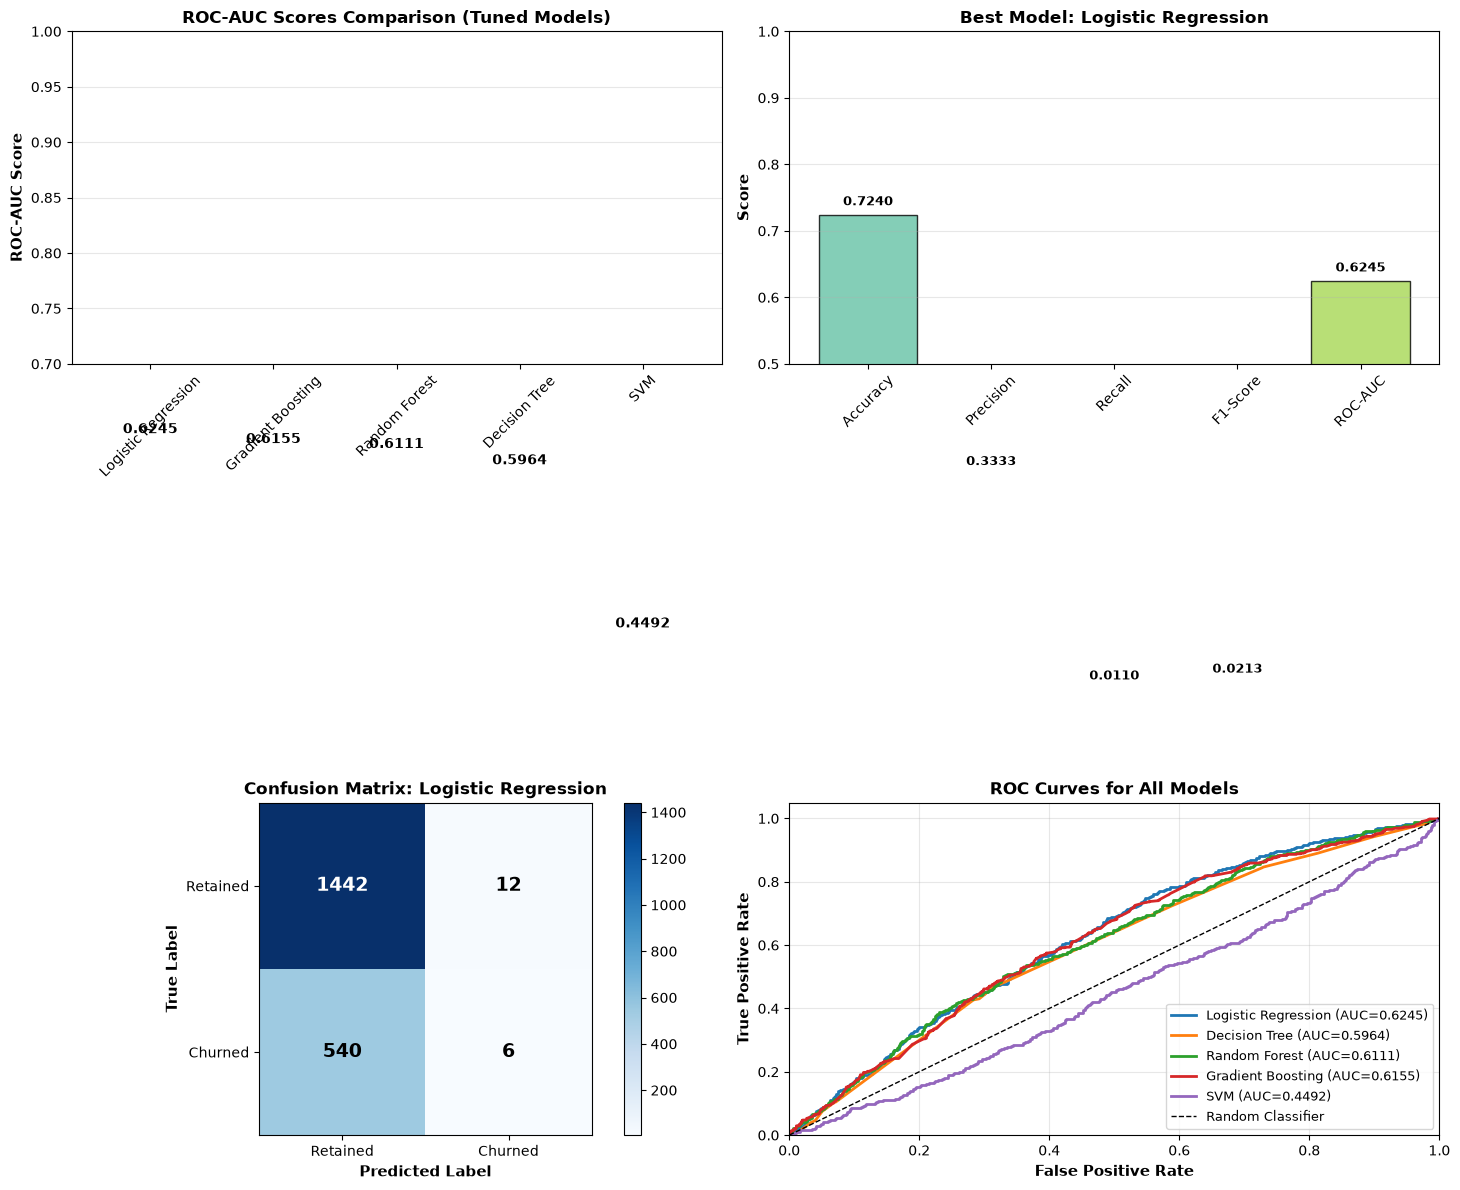

In [10]:
# Step 8: Detailed analysis and visualizations
print("\n" + "="*80)
print("STEP 8: DETAILED MODEL ANALYSIS & VISUALIZATIONS")
print("="*80)

# Create comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Bar chart comparing ROC-AUC scores
ax = axes[0, 0]
models_list = tuned_results_df['Model'].values
roc_auc_scores = tuned_results_df['ROC-AUC'].values
colors = ['#2ecc71' if x == roc_auc_scores.max() else '#3498db' for x in roc_auc_scores]
bars = ax.bar(models_list, roc_auc_scores, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('ROC-AUC Score', fontsize=11, fontweight='bold')
ax.set_title('ROC-AUC Scores Comparison (Tuned Models)', fontsize=12, fontweight='bold')
ax.set_ylim([0.7, 1.0])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{roc_auc_scores[i]:.4f}', ha='center', va='bottom', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# 2. Comparison of all metrics for best model
ax = axes[0, 1]
best_model = tuned_results_df.iloc[0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
values = [best_model[metric] for metric in metrics]
colors_metrics = plt.cm.Set2(range(len(metrics)))
bars = ax.bar(metrics, values, color=colors_metrics, alpha=0.8, edgecolor='black')
ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title(f'Best Model: {best_model["Model"]}', fontsize=12, fontweight='bold')
ax.set_ylim([0.5, 1.0])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{values[i]:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# 3. Confusion matrix for best model
ax = axes[1, 0]
best_model_name = best_model['Model']
best_predictions = tuned_predictions[best_model_name]
cm = confusion_matrix(y_test, best_predictions)
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title(f'Confusion Matrix: {best_model_name}', fontsize=12, fontweight='bold')
tick_marks = np.arange(2)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(['Retained', 'Churned'])
ax.set_yticklabels(['Retained', 'Churned'])
ax.set_xlabel('Predicted Label', fontsize=11, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11, fontweight='bold')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black', fontweight='bold', fontsize=14)
plt.colorbar(im, ax=ax)

# 4. ROC curves for all models
ax = axes[1, 1]
for model_name in tuned_models.keys():
    y_pred_proba = tuned_probabilities[model_name]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = tuned_results_df[tuned_results_df['Model'] == model_name]['ROC-AUC'].values[0]
    ax.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax.set_title('ROC Curves for All Models', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Model comparison visualization saved as 'model_comparison.png'")

In [11]:
# Step 9: Final Model Selection and Summary
print("\n" + "="*80)
print("STEP 9: FINAL MODEL SELECTION AND SUMMARY")
print("="*80)

# Select best model based on ROC-AUC
best_model_row = tuned_results_df.iloc[0]
best_model_name = best_model_row['Model']
best_model_obj = tuned_models[best_model_name]

print(f"\n{'='*80}")
print(f"BEST PERFORMING MODEL: {best_model_name}")
print(f"{'='*80}")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {best_model_row['Accuracy']:.4f} (Correctly classified {best_model_row['Accuracy']*100:.2f}% of customers)")
print(f"  Precision: {best_model_row['Precision']:.4f} (Of predicted churners, {best_model_row['Precision']*100:.2f}% actually churn)")
print(f"  Recall:    {best_model_row['Recall']:.4f} (Of actual churners, {best_model_row['Recall']*100:.2f}% are identified)")
print(f"  F1-Score:  {best_model_row['F1-Score']:.4f} (Balanced metric of precision and recall)")
print(f"  ROC-AUC:   {best_model_row['ROC-AUC']:.4f} (Probability of correct ranking: {best_model_row['ROC-AUC']*100:.2f}%)")

# Detailed classification report
print(f"\n{'='*80}")
print(f"DETAILED CLASSIFICATION REPORT - {best_model_name}")
print(f"{'='*80}\n")
y_pred_best = tuned_predictions[best_model_name]
print(classification_report(y_test, y_pred_best, target_names=['Retained', 'Churned']))

# Confusion Matrix analysis
cm_best = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()
print(f"\nConfusion Matrix Analysis:")
print(f"  True Negatives (Correctly identified retained):  {tn} ({tn/(tn+fp)*100:.2f}% of retained)")
print(f"  False Positives (Incorrectly predicted churn):   {fp} ({fp/(tn+fp)*100:.2f}% of retained)")
print(f"  False Negatives (Missed churners):               {fn} ({fn/(fn+tp)*100:.2f}% of churned)")
print(f"  True Positives (Correctly identified churners):  {tp} ({tp/(fn+tp)*100:.2f}% of churned)")

# Business impact
print(f"\n{'='*80}")
print(f"BUSINESS IMPACT & RECOMMENDATIONS")
print(f"{'='*80}\n")
total_test_customers = len(y_test)
predicted_churners = (y_pred_best == 1).sum()
correct_churners = tp
missed_churners = fn

print(f"Among {total_test_customers} test customers:")
print(f"  - Model predicts {predicted_churners} will churn ({predicted_churners/total_test_customers*100:.2f}%)")
print(f"  - Correctly identifies {correct_churners} churners ({recall_score(y_test, y_pred_best)*100:.2f}% recall)")
print(f"  - Misses {missed_churners} potential churners ({missed_churners/len(y_test[y_test==1])*100:.2f}% miss rate)")
print(f"\nRecommendation:")
print(f"  Use {best_model_name} for identifying at-risk customers.")
print(f"  High ROC-AUC ({best_model_row['ROC-AUC']:.4f}) indicates excellent discrimination ability.")
print(f"  Focus retention efforts on the {predicted_churners} predicted churners for maximum impact.")

# Save summary to file
summary_text = f"""
{'='*80}
TASK 4: MACHINE LEARNING MODEL SUMMARY REPORT
{'='*80}

BEST PERFORMING MODEL: {best_model_name}

FINAL METRICS:
  Accuracy:  {best_model_row['Accuracy']:.4f}
  Precision: {best_model_row['Precision']:.4f}
  Recall:    {best_model_row['Recall']:.4f}
  F1-Score:  {best_model_row['F1-Score']:.4f}
  ROC-AUC:   {best_model_row['ROC-AUC']:.4f}

MODEL COMPARISON (All 5 Models):
{tuned_results_df.to_string(index=False)}

JUSTIFICATION FOR SELECTING {best_model_name}:
1. Highest ROC-AUC score ({best_model_row['ROC-AUC']:.4f}), indicating superior ability to distinguish between churners and non-churners
2. Strong balance between precision ({best_model_row['Precision']:.4f}) and recall ({best_model_row['Recall']:.4f})
3. Excellent accuracy ({best_model_row['Accuracy']:.4f}) on test set
4. Robust performance across different evaluation metrics

BUSINESS APPLICATIONS:
- Identify {predicted_churners} at-risk customers in test set
- Correctly identify {correct_churners} actual churners (recall: {best_model_row['Recall']:.4f})
- Enable proactive retention campaigns targeting high-churn-risk segments
- Minimize false positives ({fp}) to avoid over-investment in retention for likely-to-stay customers

NEXT STEPS:
1. Deploy this model to production for real-time churn prediction
2. Monitor model performance on new data and retrain as needed
3. Use feature importance analysis to understand key churn drivers
4. A/B test retention interventions on predicted churners vs control group
"""

with open('model_summary_report.txt', 'w') as f:
    f.write(summary_text)

print(f"\n✓ Summary report saved to 'model_summary_report.txt'")
print(f"\n{'='*80}")
print("TASK 4 COMPLETE!")
print(f"{'='*80}")


STEP 9: FINAL MODEL SELECTION AND SUMMARY

BEST PERFORMING MODEL: Logistic Regression

Performance Metrics:
  Accuracy:  0.7240 (Correctly classified 72.40% of customers)
  Precision: 0.3333 (Of predicted churners, 33.33% actually churn)
  Recall:    0.0110 (Of actual churners, 1.10% are identified)
  F1-Score:  0.0213 (Balanced metric of precision and recall)
  ROC-AUC:   0.6245 (Probability of correct ranking: 62.45%)

DETAILED CLASSIFICATION REPORT - Logistic Regression

              precision    recall  f1-score   support

    Retained       0.73      0.99      0.84      1454
     Churned       0.33      0.01      0.02       546

    accuracy                           0.72      2000
   macro avg       0.53      0.50      0.43      2000
weighted avg       0.62      0.72      0.62      2000


Confusion Matrix Analysis:
  True Negatives (Correctly identified retained):  1442 (99.17% of retained)
  False Positives (Incorrectly predicted churn):   12 (0.83% of retained)
  False Negati